# Multimodal Learning Pipeline v2 — Late Fusion / Stacking
# Modalities : Gene Expression | Mutation | Clinical
# Targets    : OS_STATUS  |  PFS_STATUS  |  Stage (I/II/III/IV)
# Strategy   : Per-modality Level-0 models → OOF predictions → Meta-Learner


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold, cross_val_predict, train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

SEED      = 42
N_FOLDS   = 5
TEST_SIZE = 0.2
np.random.seed(SEED)

DATA_DIR      = Path('/Users/soumya/Documents/ONCOLENS/Data')
PROCESSED     = DATA_DIR / 'processed_data'
FEATURE_STORE = DATA_DIR / 'feature_store' / 'expression'

print("Libraries loaded.")

Libraries loaded.


## Section 1 — Data Loading & Alignment

In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
expr     = pd.read_csv(PROCESSED / 'selected_expression.csv')
clinical = pd.read_csv(PROCESSED / 'mutation_data_processed' / 'selected_clinical.csv')
mut      = pd.read_csv(PROCESSED / 'selected_mutation.csv', index_col=0)

# Normalise patient-ID column names
expr.rename(columns={'Patient_ID': 'patient_id'}, inplace=True)
clinical.rename(columns={'PATIENT_ID': 'patient_id'}, inplace=True)
mut.rename(columns={'Patient_ID': 'patient_id'}, inplace=True)

print(f"Expression : {expr.shape}")
print(f"Clinical   : {clinical.shape}")
print(f"Mutation   : {mut.shape}")

# ── Inner join on patient_id ───────────────────────────────────────────────────
shared = (
    set(expr['patient_id'])
    & set(clinical['patient_id'])
    & set(mut['patient_id'])
)
print(f"\nShared patients (triple overlap): {len(shared)}")

expr     = expr[expr['patient_id'].isin(shared)].set_index('patient_id').sort_index()
clinical = clinical[clinical['patient_id'].isin(shared)].set_index('patient_id').sort_index()
mut      = mut[mut['patient_id'].isin(shared)].set_index('patient_id').sort_index()

# ── Encode Stage ──────────────────────────────────────────────────────────────
clinical['Stage'] = clinical['AJCC_PATHOLOGIC_TUMOR_STAGE'].apply(
    lambda x: int(x) if pd.notna(x) else np.nan
)

# ── Class distributions ───────────────────────────────────────────────────────
print("\nOS_STATUS  :", clinical['OS_STATUS'].value_counts().sort_index().to_dict())
print("PFS_STATUS :", clinical['PFS_STATUS'].value_counts().sort_index().to_dict())
print("Stage      :", clinical['Stage'].value_counts().sort_index().to_dict())

Expression : (510, 20512)
Clinical   : (463, 11)
Mutation   : (504, 526)

Shared patients (triple overlap): 450

OS_STATUS  : {0: 285, 1: 165}
PFS_STATUS : {0: 256, 1: 194}
Stage      : {1: 247, 2: 112, 3: 68, 4: 23}


## Section 2 — Feature Preparation

In [3]:
# ── Expression: log1p + pre-selected genes from feature store ─────────────────
gene_lists = {}
for target in ['OS_STATUS', 'PFS_STATUS', 'Stage']:
    gene_file = FEATURE_STORE / target / 'gene_list.txt'
    gene_lists[target] = pd.read_csv(gene_file, header=None)[0].tolist()
    print(f"Feature-store genes ({target}): {len(gene_lists[target])}")

union_genes = sorted(set().union(*gene_lists.values()))
print(f"Union of selected genes       : {len(union_genes)}")

expr_log = np.log1p(expr)
valid_genes = [g for g in union_genes if g in expr_log.columns]
X_expr = expr_log[valid_genes].copy()
print(f"Expression feature matrix     : {X_expr.shape}")

# ── Mutation: binary gene matrix + TMB ────────────────────────────────────────
X_mut = mut.copy()
print(f"Mutation feature matrix       : {X_mut.shape}")

# ── Clinical: target-specific feature sets (remove leakage) ────────
# OS_STATUS  → all 7 features (TNM staging is a legitimate outcome predictor)
# PFS_STATUS → drop NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT (same signal as PFS)
# Stage      → drop PATH_T/N/M_STAGE (TNM components directly define AJCC stage)
CLINICAL_FEATS_PER_TARGET = {
    'OS_STATUS': [
        'HISTORY_NEOADJUVANT_TRTYN', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT',
        'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE',
        'PRIOR_DX', 'RADIATION_THERAPY',
    ],
    'PFS_STATUS': [
        'HISTORY_NEOADJUVANT_TRTYN',
        'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE',
        'PRIOR_DX', 'RADIATION_THERAPY',
    ],
    'Stage': [
        'HISTORY_NEOADJUVANT_TRTYN', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT',
        'PRIOR_DX', 'RADIATION_THERAPY',
    ],
}

X_clin_per_target = {}
for tname, feats in CLINICAL_FEATS_PER_TARGET.items():
    Xc = clinical[feats].copy()
    Xc.replace(-1, np.nan, inplace=True)
    Xc.fillna(Xc.median(), inplace=True)
    X_clin_per_target[tname] = Xc
    print(f"Clinical ({tname}): {Xc.shape[1]} features → {feats}")

Feature-store genes (OS_STATUS): 88
Feature-store genes (PFS_STATUS): 71
Feature-store genes (Stage): 99
Union of selected genes       : 248
Expression feature matrix     : (450, 248)
Mutation feature matrix       : (450, 525)
Clinical (OS_STATUS): 7 features → ['HISTORY_NEOADJUVANT_TRTYN', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE', 'PRIOR_DX', 'RADIATION_THERAPY']
Clinical (PFS_STATUS): 6 features → ['HISTORY_NEOADJUVANT_TRTYN', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE', 'PRIOR_DX', 'RADIATION_THERAPY']
Clinical (Stage): 4 features → ['HISTORY_NEOADJUVANT_TRTYN', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'PRIOR_DX', 'RADIATION_THERAPY']


## Section 3 — Level-0 Per-Modality Models (Out-of-Fold Stacking)

In [4]:
STAGE_CLASSES = [1, 2, 3, 4]

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

def make_rf():
    return RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=SEED, n_jobs=-1
    )

def make_lr():
    # saga supports L1 penalty for both binary and multiclass (liblinear doesn't)
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.05, penalty='l1', solver='saga',
            class_weight='balanced', max_iter=2000, random_state=SEED
        ))
    ])

def oof_avg(X, y, cv):
    """Average OOF probabilities from RF and LR (shape: n_train × n_classes)."""
    proba_rf = cross_val_predict(make_rf(), X, y, cv=cv, method='predict_proba')
    proba_lr = cross_val_predict(make_lr(), X, y, cv=cv, method='predict_proba')
    return (proba_rf + proba_lr) / 2

def test_avg(X_tr, y_tr, X_te):
    """Train RF + LR on full training set and return averaged test probabilities."""
    rf = make_rf(); rf.fit(X_tr, y_tr)
    lr = make_lr(); lr.fit(X_tr, y_tr)
    return (rf.predict_proba(X_te) + lr.predict_proba(X_te)) / 2, rf, lr

def compute_auc(proba, y, is_multiclass):
    if is_multiclass:
        y_bin = label_binarize(y, classes=STAGE_CLASSES)
        return roc_auc_score(y_bin, proba, multi_class='ovr', average='macro')
    return roc_auc_score(y, proba[:, 1])

print("Helper functions defined.")

Helper functions defined.


In [5]:
TARGET_CONFIG = {
    'OS_STATUS':  {'col': 'OS_STATUS',  'multiclass': False},
    'PFS_STATUS': {'col': 'PFS_STATUS', 'multiclass': False},
    'Stage':      {'col': 'Stage',      'multiclass': True},
}

MODALITIES = ['Expression', 'Mutation', 'Clinical']

# Storage for results and trained artefacts
results       = {}
stacked_store = {}

for tname, cfg in TARGET_CONFIG.items():
    y_col = cfg['col']
    is_mc = cfg['multiclass']

    # ── Filter to patients with non-NaN target ─────────────────────────────
    valid_idx = clinical[y_col].dropna().index
    y_all  = clinical.loc[valid_idx, y_col].astype(int)
    Xe_all = X_expr.loc[valid_idx]
    Xm_all = X_mut.loc[valid_idx]
    Xc_all = X_clin_per_target[tname].loc[valid_idx]   # target-specific clinical features

    # ── Stratified train / test split ─────────────────────────────────────
    idx = np.arange(len(y_all))
    tr_idx, te_idx = train_test_split(
        idx, test_size=TEST_SIZE, stratify=y_all.values, random_state=SEED
    )
    Xe_tr, Xe_te = Xe_all.iloc[tr_idx], Xe_all.iloc[te_idx]
    Xm_tr, Xm_te = Xm_all.iloc[tr_idx], Xm_all.iloc[te_idx]
    Xc_tr, Xc_te = Xc_all.iloc[tr_idx], Xc_all.iloc[te_idx]
    y_tr,  y_te  = y_all.iloc[tr_idx],  y_all.iloc[te_idx]

    modality_data = {
        'Expression': (Xe_tr, Xe_te),
        'Mutation':   (Xm_tr, Xm_te),
        'Clinical':   (Xc_tr, Xc_te),
    }

    print(f"\n{'='*60}")
    print(f"Target: {tname}  |  train={len(y_tr)}, test={len(y_te)}")
    print(f"  Classes: {dict(y_tr.value_counts().sort_index())}")
    print(f"  Clinical features used: {list(Xc_tr.columns)}")

    oof_proba      = {}
    test_proba     = {}
    trained_models = {}

    for mname, (Xtr, Xte) in modality_data.items():
        oof  = oof_avg(Xtr, y_tr, cv)
        tproba, rf_fit, lr_fit = test_avg(Xtr, y_tr, Xte)
        auc  = compute_auc(oof, y_tr, is_mc)
        print(f"  {mname:<12} CV AUC (OOF): {auc:.3f}")

        oof_proba[mname]      = oof
        test_proba[mname]     = tproba
        trained_models[mname] = {'rf': rf_fit, 'lr': lr_fit}

    results[tname] = {
        'modality_cv_auc': {
            m: compute_auc(oof_proba[m], y_tr, is_mc) for m in MODALITIES
        },
        'trained_models': trained_models,
        'is_multiclass':  is_mc,
        'y_tr': y_tr, 'y_te': y_te,
        'oof_proba':  oof_proba,
        'test_proba': test_proba,
    }


Target: OS_STATUS  |  train=360, test=90
  Classes: {0: np.int64(228), 1: np.int64(132)}
  Clinical features used: ['HISTORY_NEOADJUVANT_TRTYN', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE', 'PRIOR_DX', 'RADIATION_THERAPY']
  Expression   CV AUC (OOF): 0.685
  Mutation     CV AUC (OOF): 0.521
  Clinical     CV AUC (OOF): 0.722

Target: PFS_STATUS  |  train=360, test=90
  Classes: {0: np.int64(205), 1: np.int64(155)}
  Clinical features used: ['HISTORY_NEOADJUVANT_TRTYN', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE', 'PRIOR_DX', 'RADIATION_THERAPY']
  Expression   CV AUC (OOF): 0.608
  Mutation     CV AUC (OOF): 0.494
  Clinical     CV AUC (OOF): 0.615

Target: Stage  |  train=360, test=90
  Classes: {1: np.int64(198), 2: np.int64(90), 3: np.int64(54), 4: np.int64(18)}
  Clinical features used: ['HISTORY_NEOADJUVANT_TRTYN', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'PRIOR_DX', 'RADIATION_THERAPY']
  Expression   CV AUC (OOF): 0.585
  Muta

## Section 4 — Meta-Learner (Level-1 Stacking)

In [6]:
for tname, res in results.items():
    is_mc      = res['is_multiclass']
    oof_proba  = res['oof_proba']
    test_proba = res['test_proba']
    y_tr       = res['y_tr']
    y_te       = res['y_te']

    # ── Build meta-feature matrices ────────────────────────────────────────
    if is_mc:
        # Stack all class probabilities per modality → (n, 3 × n_classes)
        meta_tr = np.hstack([oof_proba[m]  for m in MODALITIES])
        meta_te = np.hstack([test_proba[m] for m in MODALITIES])
    else:
        # Stack positive-class probability per modality → (n, 3)
        meta_tr = np.column_stack([oof_proba[m][:, 1]  for m in MODALITIES])
        meta_te = np.column_stack([test_proba[m][:, 1] for m in MODALITIES])

    # ── Fit meta-learner on OOF predictions ───────────────────────────────
    meta_clf = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
    meta_clf.fit(meta_tr, y_tr)

    # ── Evaluate on held-out test set ─────────────────────────────────────
    meta_te_proba = meta_clf.predict_proba(meta_te)
    stacked_auc   = compute_auc(meta_te_proba, y_te, is_mc)

    # Predictions for classification report
    meta_te_preds = meta_clf.predict(meta_te)

    res['meta_clf']     = meta_clf
    res['stacked_auc']  = stacked_auc
    res['meta_te_proba'] = meta_te_proba
    res['meta_te_preds'] = meta_te_preds

    print(f"\n{'='*60}")
    print(f"Target: {tname}")
    print(f"  Per-modality CV AUC (OOF, train set):")
    for m in MODALITIES:
        print(f"    {m:<12}: {res['modality_cv_auc'][m]:.3f}")
    print(f"  >>> Stacked test AUC : {stacked_auc:.3f}")
    print()
    print(classification_report(y_te, meta_te_preds))


Target: OS_STATUS
  Per-modality CV AUC (OOF, train set):
    Expression  : 0.685
    Mutation    : 0.521
    Clinical    : 0.722
  >>> Stacked test AUC : 0.784

              precision    recall  f1-score   support

           0       0.72      0.89      0.80        57
           1       0.68      0.39      0.50        33

    accuracy                           0.71        90
   macro avg       0.70      0.64      0.65        90
weighted avg       0.71      0.71      0.69        90


Target: PFS_STATUS
  Per-modality CV AUC (OOF, train set):
    Expression  : 0.608
    Mutation    : 0.494
    Clinical    : 0.615
  >>> Stacked test AUC : 0.728

              precision    recall  f1-score   support

           0       0.61      0.90      0.73        51
           1       0.67      0.26      0.37        39

    accuracy                           0.62        90
   macro avg       0.64      0.58      0.55        90
weighted avg       0.64      0.62      0.57        90


Target: Stage
  Pe

## Section 5 — Results Comparison

            Expression (CV AUC)  Mutation (CV AUC)  Clinical (CV AUC)  Stacked (test AUC)
Target                                                                                   
OS_STATUS                 0.685              0.521              0.722               0.784
PFS_STATUS                0.608              0.494              0.615               0.728
Stage                     0.585              0.444              0.590               0.609


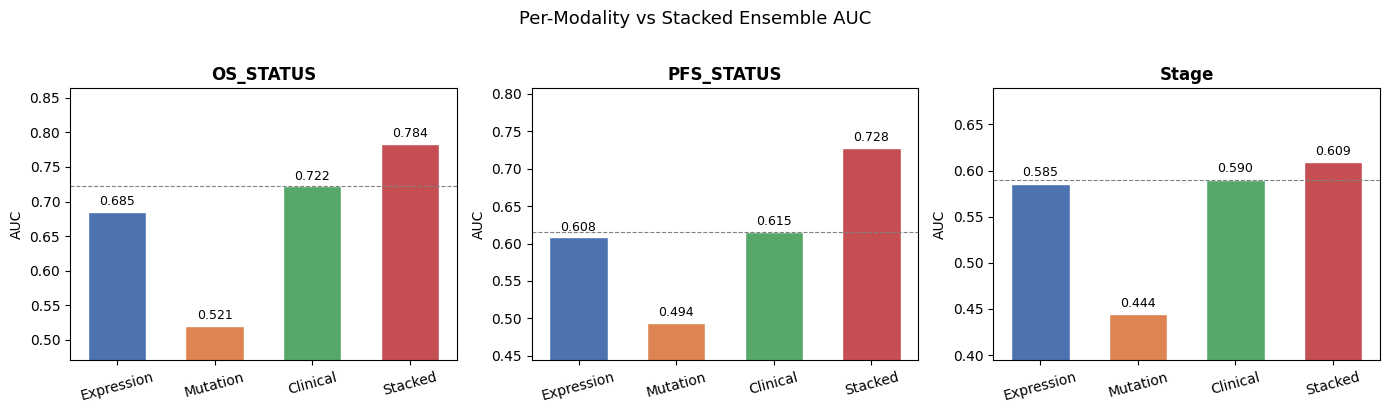

In [7]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for tname, res in results.items():
    row = {'Target': tname}
    for m in MODALITIES:
        row[f'{m} (CV AUC)'] = round(res['modality_cv_auc'][m], 3)
    row['Stacked (test AUC)'] = round(res['stacked_auc'], 3)
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Target')
print(summary.to_string())

# ── Bar chart: modality AUC vs stacked AUC ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, (tname, res) in zip(axes, results.items()):
    labels = MODALITIES + ['Stacked']
    aucs   = [res['modality_cv_auc'][m] for m in MODALITIES] + [res['stacked_auc']]
    colors = palette[:3] + [palette[3]]
    bars = ax.bar(labels, aucs, color=colors, edgecolor='white', width=0.6)
    ax.set_title(tname, fontsize=12, fontweight='bold')
    ax.set_ylabel('AUC')
    ax.set_ylim(max(0, min(aucs) - 0.05), min(1.0, max(aucs) + 0.08))
    ax.axhline(max(aucs[:3]), color='grey', linestyle='--', linewidth=0.8,
               label='Best single-modality')
    for bar, val in zip(bars, aucs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Per-Modality vs Stacked Ensemble AUC', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Section 6 — Feature Importance

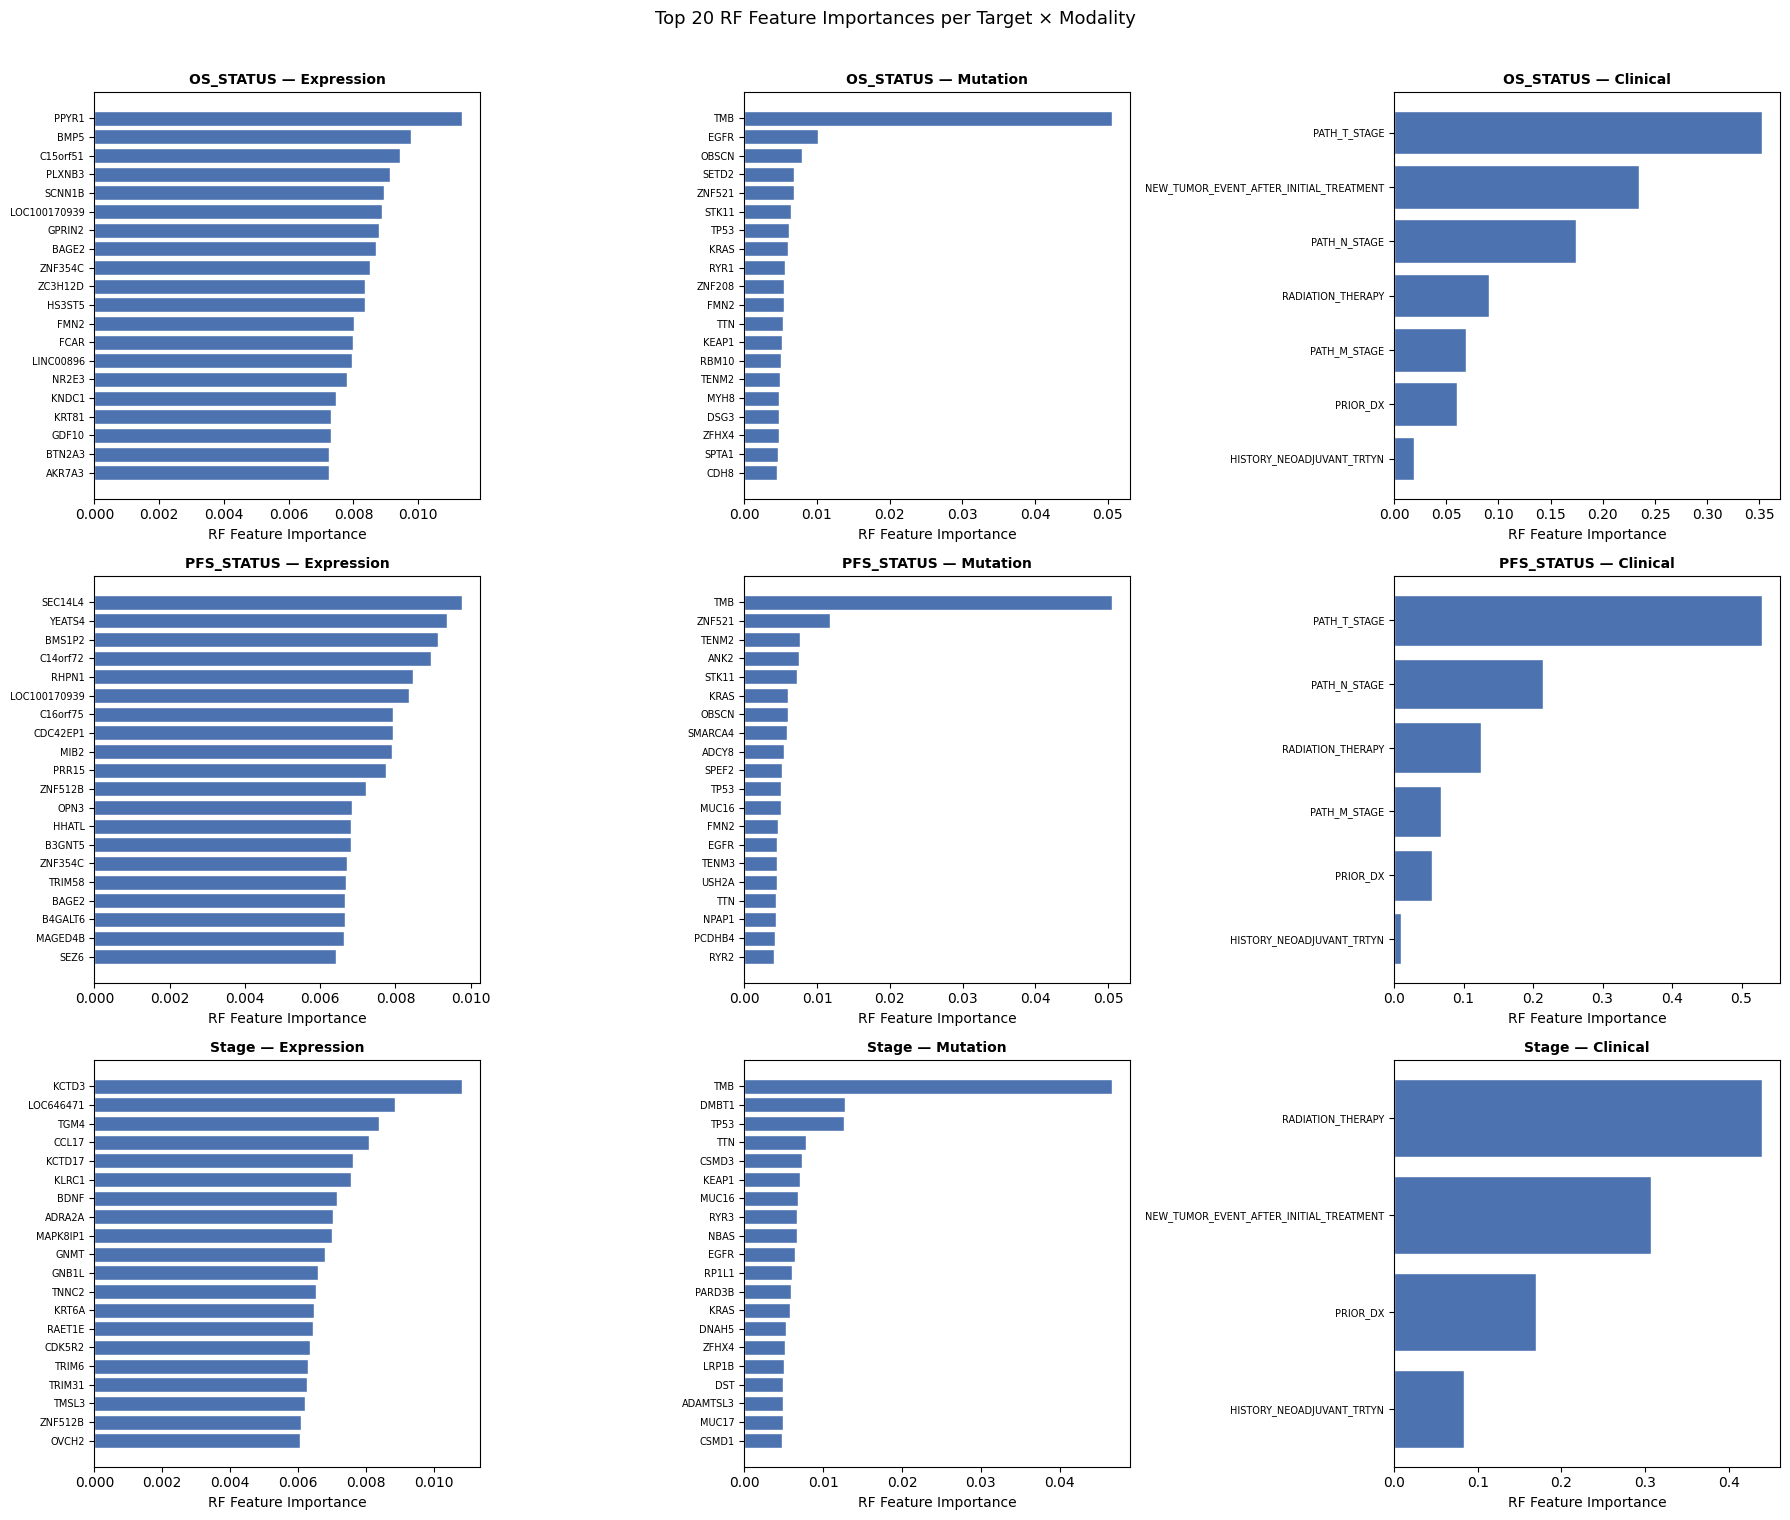

In [8]:
TOP_N = 20

# Feature names are target-specific for Clinical (different columns per target)
FEAT_NAMES_PER_TARGET = {
    tname: {
        'Expression': valid_genes,
        'Mutation':   list(X_mut.columns),
        'Clinical':   CLINICAL_FEATS_PER_TARGET[tname],
    }
    for tname in TARGET_CONFIG
}

fig, axes = plt.subplots(len(results), len(MODALITIES),
                          figsize=(18, 5 * len(results)))

for row_i, (tname, res) in enumerate(results.items()):
    for col_i, mname in enumerate(MODALITIES):
        ax         = axes[row_i, col_i]
        rf         = res['trained_models'][mname]['rf']
        feat_names = FEAT_NAMES_PER_TARGET[tname][mname]

        importances = rf.feature_importances_ if hasattr(rf, 'feature_importances_') \
                      else np.zeros(len(feat_names))

        top_idx   = np.argsort(importances)[::-1][:TOP_N]
        top_names = [feat_names[i] for i in top_idx]
        top_vals  = importances[top_idx]

        ax.barh(top_names[::-1], top_vals[::-1], color='#4C72B0', edgecolor='white')
        ax.set_title(f'{tname} — {mname}', fontsize=10, fontweight='bold')
        ax.set_xlabel('RF Feature Importance')
        ax.tick_params(axis='y', labelsize=7)

plt.suptitle(f'Top {TOP_N} RF Feature Importances per Target × Modality',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Normalised meta-learner modality weights:

            Expression  Mutation  Clinical
Target                                    
OS_STATUS        0.423     0.040     0.537
PFS_STATUS       0.471     0.007     0.522
Stage            0.371     0.224     0.404


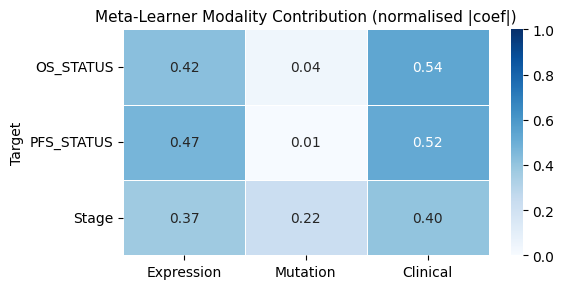

In [9]:
# ── Meta-learner modality weights ─────────────────────────────────────────────
# For binary targets: 3 coefficients (one per modality OOF probability).
# For Stage (multiclass): 12 coefficients (3 modalities × 4 class probs);
#   we sum absolute values across class probabilities per modality to get a
#   single importance score per modality.

weight_rows = []
for tname, res in results.items():
    meta_clf = res['meta_clf']
    is_mc    = res['is_multiclass']
    coefs    = meta_clf.coef_   # shape: (1, 3) binary or (n_classes, 3*n_classes) multi

    if is_mc:
        # coefs shape: (n_classes, 3 * n_classes) — group by modality blocks
        n_classes = len(STAGE_CLASSES)
        weights = {}
        for mi, mname in enumerate(MODALITIES):
            # Each modality contributes n_classes consecutive columns
            block = coefs[:, mi * n_classes : (mi + 1) * n_classes]
            weights[mname] = np.abs(block).sum()
        # Normalise to sum to 1
        total = sum(weights.values())
        weight_rows.append({**{'Target': tname}, **{k: v / total for k, v in weights.items()}})
    else:
        coef_1d = coefs[0]   # (3,) — one per modality
        total   = np.abs(coef_1d).sum()
        weight_rows.append({
            'Target':      tname,
            'Expression':  abs(coef_1d[0]) / total,
            'Mutation':    abs(coef_1d[1]) / total,
            'Clinical':    abs(coef_1d[2]) / total,
        })

weight_df = pd.DataFrame(weight_rows).set_index('Target')
print("Normalised meta-learner modality weights:\n")
print(weight_df.round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(weight_df.astype(float), annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('Meta-Learner Modality Contribution (normalised |coef|)', fontsize=11)
plt.tight_layout()
plt.show()

## Section 7 — Save Final Multimodal Model

Persist the exact evaluated 360/90 multimodal stacked models to the feature store for reproducible downstream experiments.



In [10]:
import json
import joblib
from datetime import datetime

MULTIMODAL_STORE = DATA_DIR / 'feature_store' / 'multimodal_model'
MULTIMODAL_STORE.mkdir(parents=True, exist_ok=True)
REGISTRY_PATH = DATA_DIR / 'feature_store' / 'registry_multimodal.json'
DECISION_THRESHOLD = 0.5


def json_safe(value):
    """Convert numpy/pandas values into JSON-serialisable Python objects."""
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    if isinstance(value, np.ndarray):
        return json_safe(value.tolist())
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if pd.isna(value) if isinstance(value, (float, np.floating)) else False:
        return None
    return value


def class_distribution(y):
    return {str(k): int(v) for k, v in y.value_counts().sort_index().items()}


def clinical_preprocessing_state(tname):
    feats = CLINICAL_FEATS_PER_TARGET[tname]
    raw = clinical[feats].copy()
    raw.replace(-1, np.nan, inplace=True)
    return {
        'replace_minus_one_with_nan': True,
        'median_imputation_values': json_safe(raw.median().to_dict()),
        'stage_mapping': {
            'source_column': 'AJCC_PATHOLOGIC_TUMOR_STAGE',
            'rule': 'int(value) when value is not missing',
            'classes': STAGE_CLASSES,
        },
    }


def build_meta_features_from_level0(level0, modality_order, is_multiclass, X_by_modality):
    modality_proba = []
    for mname in modality_order:
        rf_model = level0[mname]['rf']
        lr_model = level0[mname]['lr']
        X = X_by_modality[mname][level0[mname]['feature_names']]
        proba = (rf_model.predict_proba(X) + lr_model.predict_proba(X)) / 2
        modality_proba.append(proba if is_multiclass else proba[:, 1])

    if is_multiclass:
        return np.hstack(modality_proba)
    return np.column_stack(modality_proba)


registry = {}

for tname, res in results.items():
    target_dir = MULTIMODAL_STORE / tname
    target_dir.mkdir(parents=True, exist_ok=True)

    is_mc = res['is_multiclass']
    y_tr = res['y_tr']
    y_te = res['y_te']
    train_patient_ids = [str(pid) for pid in y_tr.index]
    test_patient_ids = [str(pid) for pid in y_te.index]

    expression_features = list(FEAT_NAMES_PER_TARGET[tname]['Expression'])
    mutation_features = list(FEAT_NAMES_PER_TARGET[tname]['Mutation'])
    clinical_features = list(FEAT_NAMES_PER_TARGET[tname]['Clinical'])

    feature_manifest = {
        'target': tname,
        'feature_order': MODALITIES,
        'Expression': expression_features,
        'Mutation': mutation_features,
        'Clinical': clinical_features,
    }

    feature_counts = {
        'Expression': len(expression_features),
        'Mutation': len(mutation_features),
        'Clinical': len(clinical_features),
    }

    classification_metrics = classification_report(
        y_te,
        res['meta_te_preds'],
        output_dict=True,
        zero_division=0,
    )

    metadata = {
        'target': tname,
        'model_type': 'Multimodal Late-Fusion Stacking',
        'level0_model_types': {
            'rf': 'RandomForestClassifier',
            'lr': 'LogisticRegression with StandardScaler pipeline',
        },
        'level1_model_type': 'LogisticRegression',
        'is_multiclass': bool(is_mc),
        'classes': json_safe(res['meta_clf'].classes_.tolist()),
        'total_patients': int(len(clinical)),
        'train_patients': int(len(y_tr)),
        'test_patients': int(len(y_te)),
        'train_patient_ids': train_patient_ids,
        'test_patient_ids': test_patient_ids,
        'train_class_distribution': class_distribution(y_tr),
        'test_class_distribution': class_distribution(y_te),
        'seed': SEED,
        'folds': N_FOLDS,
        'test_size': TEST_SIZE,
        'feature_counts': feature_counts,
        'modality_oof_auc': {
            m: round(float(res['modality_cv_auc'][m]), 6) for m in MODALITIES
        },
        'stacked_heldout_test_auc': round(float(res['stacked_auc']), 6),
        'classification_metrics': json_safe(classification_metrics),
        'decision_threshold': DECISION_THRESHOLD,
        'meta_feature_order': MODALITIES,
        'meta_feature_mode': 'all_class_probabilities' if is_mc else 'positive_class_probabilities',
        'created_at': datetime.now().isoformat(timespec='seconds'),
    }

    bundle = {
        'target': tname,
        'level0': {
            'Expression': {
                'rf': res['trained_models']['Expression']['rf'],
                'lr': res['trained_models']['Expression']['lr'],
                'feature_names': expression_features,
                'selected_genes': expression_features,
                'preprocessing': {
                    'log1p': True,
                    'selected_genes': expression_features,
                },
            },
            'Mutation': {
                'rf': res['trained_models']['Mutation']['rf'],
                'lr': res['trained_models']['Mutation']['lr'],
                'feature_names': mutation_features,
                'preprocessing': {
                    'mutation_column_order': mutation_features,
                    'tmb_included': 'TMB' in mutation_features,
                },
            },
            'Clinical': {
                'rf': res['trained_models']['Clinical']['rf'],
                'lr': res['trained_models']['Clinical']['lr'],
                'feature_names': clinical_features,
                'preprocessing': clinical_preprocessing_state(tname),
            },
        },
        'level1': {
            'meta_model': res['meta_clf'],
            'feature_order': MODALITIES,
            'meta_feature_mode': metadata['meta_feature_mode'],
        },
        'metadata': metadata,
    }

    # Save model bundle and sidecar files.
    bundle_path = target_dir / 'multimodal_stack.joblib'
    metadata_path = target_dir / 'metadata.json'
    manifest_path = target_dir / 'features_manifest.json'
    predictions_path = target_dir / 'test_predictions.csv'

    joblib.dump(bundle, bundle_path)

    with open(metadata_path, 'w') as f:
        json.dump(json_safe(metadata), f, indent=2)

    with open(manifest_path, 'w') as f:
        json.dump(json_safe(feature_manifest), f, indent=2)

    pred_df = pd.DataFrame({
        'patient_id': test_patient_ids,
        'true_label': y_te.astype(int).values,
        'predicted_label': res['meta_te_preds'].astype(int),
    })
    if is_mc:
        for class_label, col_idx in zip(res['meta_clf'].classes_, range(res['meta_te_proba'].shape[1])):
            pred_df[f'probability_class_{class_label}'] = res['meta_te_proba'][:, col_idx]
    else:
        pred_df['predicted_probability'] = res['meta_te_proba'][:, 1]
    pred_df.to_csv(predictions_path, index=False)

    # Reload validation: rebuild held-out meta-features from saved final Level-0 models.
    reloaded = joblib.load(bundle_path)
    X_test_by_modality = {
        'Expression': X_expr.loc[y_te.index],
        'Mutation': X_mut.loc[y_te.index],
        'Clinical': X_clin_per_target[tname].loc[y_te.index],
    }
    reloaded_meta_te = build_meta_features_from_level0(
        reloaded['level0'],
        reloaded['level1']['feature_order'],
        reloaded['metadata']['is_multiclass'],
        X_test_by_modality,
    )
    reloaded_proba = reloaded['level1']['meta_model'].predict_proba(reloaded_meta_te)
    reloaded_auc = compute_auc(reloaded_proba, y_te, is_mc)
    saved_auc = metadata['stacked_heldout_test_auc']
    if not np.isclose(round(float(reloaded_auc), 6), saved_auc, atol=1e-6):
        raise ValueError(
            f"Reload validation failed for {tname}: "
            f"recomputed AUC={reloaded_auc:.6f}, saved AUC={saved_auc:.6f}"
        )

    registry[tname] = {
        'target': tname,
        'artifact_path': str(bundle_path),
        'metadata_path': str(metadata_path),
        'features_manifest_path': str(manifest_path),
        'test_predictions_path': str(predictions_path),
        'stacked_heldout_test_auc': saved_auc,
        'train_patients': metadata['train_patients'],
        'test_patients': metadata['test_patients'],
        'created_at': metadata['created_at'],
    }

    print(
        f"Saved {tname:<10} | train={len(y_tr):>3} test={len(y_te):>2} | "
        f"AUC={saved_auc:.3f} | validated reload AUC={reloaded_auc:.3f}"
    )

with open(REGISTRY_PATH, 'w') as f:
    json.dump(json_safe(registry), f, indent=2)

print(f"\nMultimodal feature store saved → {MULTIMODAL_STORE}")
print(f"Registry saved → {REGISTRY_PATH}")



Saved OS_STATUS  | train=360 test=90 | AUC=0.784 | validated reload AUC=0.784
Saved PFS_STATUS | train=360 test=90 | AUC=0.728 | validated reload AUC=0.728
Saved Stage      | train=360 test=90 | AUC=0.609 | validated reload AUC=0.609

Multimodal feature store saved → /Users/soumya/Documents/ONCOLENS/Data/feature_store/multimodal_model
Registry saved → /Users/soumya/Documents/ONCOLENS/Data/feature_store/registry_multimodal.json
